In [ ]:
import torch
import numpy as np

In [ ]:
x=torch.tensor([2,4,5,6])
print(x)

tensor([2, 4, 5, 6])


In [ ]:
x=torch.rand(2,2)
y=torch.rand(2,2)
print(x)
print(y)
# z=x+y
z=torch.add(x,y)
print(z)
#in pytorch all the functions with tarilign underscore do implace operations
y.add_(x)
print(y)

tensor([[0.0412, 0.4646],
        [0.2417, 0.8924]])
tensor([[0.1815, 0.1455],
        [0.7153, 0.7908]])
tensor([[0.2227, 0.6101],
        [0.9570, 1.6832]])
tensor([[0.2227, 0.6101],
        [0.9570, 1.6832]])


In [ ]:
x1=torch.rand(2,2)
y1=torch.rand(2,2)
z=x*y
print(x)
print(y)
print(z)
z=x/y
print(z)

tensor([[0.0412, 0.4646],
        [0.2417, 0.8924]])
tensor([[0.2227, 0.6101],
        [0.9570, 1.6832]])
tensor([[0.0092, 0.2834],
        [0.2313, 1.5022]])
tensor([[0.1851, 0.7615],
        [0.2526, 0.5302]])


In [ ]:
x=torch.rand([5,3])
print(x)
print(x[1,1])
print(x[1,1].item())#gives actual value


tensor([[0.1513, 0.1067, 0.7555],
        [0.3059, 0.8487, 0.1234],
        [0.7785, 0.8182, 0.1637],
        [0.2970, 0.6642, 0.4034],
        [0.3989, 0.1100, 0.4043]])
tensor(0.8487)
0.8486913442611694


In [ ]:
x=torch.rand(4,4)
print(x)
y=x.view(2,8)
print(y)

tensor([[0.9258, 0.7521, 0.7445, 0.9642],
        [0.5463, 0.7296, 0.3799, 0.6807],
        [0.3623, 0.8244, 0.6241, 0.5749],
        [0.3049, 0.4135, 0.2649, 0.8774]])
tensor([[0.9258, 0.7521, 0.7445, 0.9642, 0.5463, 0.7296, 0.3799, 0.6807],
        [0.3623, 0.8244, 0.6241, 0.5749, 0.3049, 0.4135, 0.2649, 0.8774]])


In [ ]:
x=torch.ones(2)
print(x)
y=x.numpy()
print(type(y))
x.add_(1)
print(y) #if tensor is on gpu

tensor([1., 1.])
<class 'numpy.ndarray'>
[2. 2.]


In [ ]:
if torch.cuda.is_available():
  print("haha")
x=torch.rand(5,3,requires_grad=True)#this shows that in future you may be doing gradient descent or optimization

In [ ]:
x=torch.rand(3,requires_grad=True)
y=x+2
print(x)
print(y)
z=y*y*2
z=z.mean()#clacluates the mean of all avlues and store it in z do basically z is a single value atp
print(z)

z.backward()# starts going backward and calcultes partial differential and multiply them
print(x.grad)

print("NEW")
z=y*y*2
print(z)
v=torch.tensor([0.1,1.0,0.001],dtype=torch.float32)#here as it is a non-scalar value we need to concretly define a L fucntion which chnages when the values of x chnages that we define as L=Evixi now we calculate gard as del L/del x as del L/del Z x del Z by del X
z.backward(v)
print(x.grad)

tensor([0.4904, 0.0471, 0.7117], requires_grad=True)
tensor([2.4904, 2.0471, 2.7117], grad_fn=<AddBackward0>)
tensor(11.8307, grad_fn=<MeanBackward0>)
tensor([3.3206, 2.7295, 3.6156])
NEW
tensor([12.4044,  8.3814, 14.7063], grad_fn=<MulBackward0>)
tensor([ 4.3167, 10.9180,  3.6264])


In [ ]:
# we don't want to calculate the gradient because it may happen that you want to stop the gradient here or that this tensor should not affect the gradient for that:
x=torch.randn(2,requires_grad=True)
print(x)
#x.requires_grad_(False)
#x=x.detach()
with torch.no_grad():
  y=x+2
  print(y)

tensor([-1.0453,  0.3595], requires_grad=True)
tensor([0.9547, 2.3595])


In [ ]:
x=torch.tensor(1.0)
y=torch.tensor(2.0)
w=torch.tensor(1.0,requires_grad=True)
# forward pass
y_hat=w*x
loss =(y_hat-y)**2
print(loss)

#backward pass
loss.backward()
print(w.grad)

tensor(1., grad_fn=<PowBackward0>)
tensor(-2.)


In [ ]:
# complete forward and backward pass manually
import numpy as np
X=np.array([1,2,3,4],dtype=np.float32)
Y=np.array([2,4,6,8],dtype=np.float32)
w=0.0

# model prediction
def forward(x):
  return w*x

# loss = MSE
def loss(y,y_predicted):
  return ((y_predicted-y)**2).mean()

# gradient
# MSE=1/N (y_hat-y)**2
# dJ/dw = 1/N * 2* (y_hat-y)*x
def gradient(x,y,y_predicted):
  return np.dot(2*x,y_predicted-y).mean()

print(f"Prediction before training f(5): {forward(5)}")

#training
lr=0.01
n_iter=10

for epochs in range  (n_iter):
  y_pred=forward(X)
  l=loss(Y,y_pred)
  dw = gradient(X,Y,y_pred)
  w=w-lr*dw

  print(f"epoch: {epochs+1}, w={w:.3f}, loss= {loss}")
print(f"After prediction: {forward(5)}")

Prediction before training f(5): 0.0
epoch: 1, w=1.200, loss= <function loss at 0x7c4ab012d760>
epoch: 2, w=1.680, loss= <function loss at 0x7c4ab012d760>
epoch: 3, w=1.872, loss= <function loss at 0x7c4ab012d760>
epoch: 4, w=1.949, loss= <function loss at 0x7c4ab012d760>
epoch: 5, w=1.980, loss= <function loss at 0x7c4ab012d760>
epoch: 6, w=1.992, loss= <function loss at 0x7c4ab012d760>
epoch: 7, w=1.997, loss= <function loss at 0x7c4ab012d760>
epoch: 8, w=1.999, loss= <function loss at 0x7c4ab012d760>
epoch: 9, w=1.999, loss= <function loss at 0x7c4ab012d760>
epoch: 10, w=2.000, loss= <function loss at 0x7c4ab012d760>
After prediction: 9.99895191192627


In [ ]:
# complete forward pass manually but gradient fucntion used for backward pass

X=torch.tensor([1,2,3,4],dtype=torch.float32)
Y=torch.tensor([2,4,6,8],dtype=torch.float32)
w=torch.tensor(0.0,dtype=torch.float32,requires_grad=True)



# model prediction
def forward(x):
  return w*x

# loss = MSE
def loss(y,y_predicted):
  return ((y_predicted-y)**2).mean()

print(f"Prediction before training f(5): {forward(5)}")

#training
lr=0.01
n_iter=20

for epochs in range  (n_iter):
  y_pred=forward(X)
  l=loss(Y,y_pred)
  l.backward()
  # backward pass
  with torch.no_grad():
   w-=lr*w.grad
  #zero the weighths
  w.grad.zero_()

  print(f"epoch: {epochs+1}, w={w:.3f}, loss= {l}")
print(f"After prediction: {forward(5)}")

In [ ]:
# complete forward pass manually but gradient fucntion used for backward pass
import torch.nn as nn
X=torch.tensor([[1],[2],[3],[4]],dtype=torch.float32)# 4 samples each conatining one feature
Y=torch.tensor([[2],[4],[6],[8]],dtype=torch.float32)
n_sample,n_features=X.shape
print(n_sample,n_features)
input_size=n_features
output_size=n_features
X_test=torch.tensor([5],dtype=torch.float32)
learning_rate=0.03
n_iter=100
#model prediction
model=nn.Linear(input_size,output_size)

# loss
loss=nn.MSELoss()
# optimizer for loss
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

print(f"Prediction before training f(5): {model(X_test).item():.3f}")

#training
for epochs in range  (n_iter):
  y_pred=model(X)
  l=loss(Y,y_pred)
  l.backward()
  # backward pass
  optimizer.step()
  #zero the weighths
  optimizer.zero_grad()
  if(epochs%10==0):
    [w,b]=model.parameters()
    print(f"epoch: {epochs+1}, w={w.item():.3f}, loss= {l}")


# final result
print(f"After prediction: {model(X_test).item():.3f}")

4 1
Prediction before training f(5): 1.830
epoch: 1, w=0.997, loss= 18.758811950683594
epoch: 11, w=1.728, loss= 0.10862218588590622
epoch: 21, w=1.752, loss= 0.09067416936159134
epoch: 31, w=1.773, loss= 0.0757036954164505
epoch: 41, w=1.793, loss= 0.063204824924469
epoch: 51, w=1.811, loss= 0.052769631147384644
epoch: 61, w=1.827, loss= 0.04405719041824341
epoch: 71, w=1.842, loss= 0.036783285439014435
epoch: 81, w=1.855, loss= 0.030710281804203987
epoch: 91, w=1.868, loss= 0.02563999406993389
After prediction: 9.749


epoch=0, loss=5678.902
epoch=10, loss=4207.630
epoch=20, loss=3143.879
epoch=30, loss=2373.908
epoch=40, loss=1816.003
epoch=50, loss=1411.369
epoch=60, loss=1117.636
epoch=70, loss=904.234
epoch=80, loss=749.077
epoch=90, loss=636.190


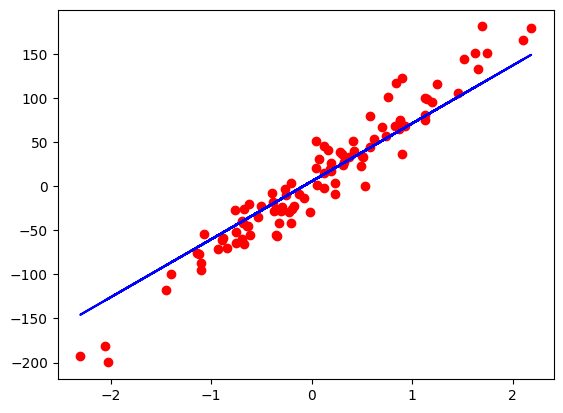

In [ ]:
# 1)design model (input,output,forward pass)
# 2) construct loss and optimizer
# 3) training loop:
      # -forward pass: compute predcition
      # -backward pass : gradients
      # - ipadting the parameters/weights
import torch
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
import torch.nn as nn


# 0) preparinf dataset
X_numpy, y_numpy = datasets.make_regression(n_samples=100,n_features=1,noise=20,random_state=1)
X=torch.from_numpy(X_numpy.astype(np.float32))
Y=torch.from_numpy(y_numpy.astype(np.float32))
Y=Y.view(Y.shape[0],1)
n_samples,n_features=X.shape

# 1) model
input_size=n_features
output_size=n_features
model=nn.Linear(input_size,output_size)

# 2) optimizer
learning_rate=0.01
criterion=nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

# 3) training
num_epochs=100
for epochs in range(num_epochs):
  #forward
  y_pred=model(X)
  loss=criterion(y_pred,Y)
  #backward
  loss.backward()
  #update of weights
  optimizer.step()

  optimizer.zero_grad()

  if (epochs%10==0):
    print(f"epoch={epochs}, loss={loss.item():.3f}")

predicted=model(X).detach().numpy()
plt.plot(X_numpy,y_numpy,"ro")
plt.plot(X_numpy,predicted,"b")
plt.show()

In [ ]:
# 1)design model (input,output,forward pass)
# 2) construct loss and optimizer
# 3) training loop:
      # -forward pass: compute predcition
      # -backward pass : gradients
      # - ipadting the parameters/weights

import torch
import torch.nn as nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# 0) preprocessing of data
bc=datasets.load_breast_cancer()
X,y=bc.data,bc.target
n_shape,n_features=X.shape
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1234)


#scale
sc=StandardScaler()#mean is zero and unit variance
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

X_train=torch.from_numpy(X_train.astype(np.float32))
X_test=torch.from_numpy(X_test.astype(np.float32))
y_train=torch.from_numpy(y_train.astype(np.float32))
y_test=torch.from_numpy(y_test.astype(np.float32))

y_train=y_train.view(y_train.shape[0],1)
y_test=y_test.view(y_test.shape[0],1)

# 1) model
# f=wx + b, sigmoid at the end
class LogisticRegression(nn.Module):

  def __init__(self,input_features):
    super(LogisticRegression,self).__init__()
    self.linear=nn.Linear(input_features,1)

  def forward(self,x):
    y_predicted=torch.sigmoid(self.linear(x))
    return y_predicted
model=LogisticRegression(n_features)
# 2)Loss and optimizer
learning_rate=0.05
criterion=nn.BCELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

# training loop
num_epochs=10000
for epoch in range(num_epochs):
  # forward pass
  y_predicted=model(X_train)
  loss=criterion(y_predicted,y_train)

  # backward pass
  loss.backward()

  # upadting steps
  optimizer.step()
  # clearing the weights
  optimizer.zero_grad()

  if (epoch+1)%1000==0:
    print(f"epoch={epoch+1}, loss={loss.item():.4f}")

with torch.no_grad():
  y_predicted=model(X_test)
  y_predicted_cls=y_predicted.round()
  acc=y_predicted_cls.eq(y_test).sum()/(float)(y_test.shape[0])
  print(f"Accuracy is: {acc}")


epoch=1000, loss=0.0502
epoch=2000, loss=0.0405
epoch=3000, loss=0.0359
epoch=4000, loss=0.0331
epoch=5000, loss=0.0312
epoch=6000, loss=0.0297
epoch=7000, loss=0.0286
epoch=8000, loss=0.0276
epoch=9000, loss=0.0268
epoch=10000, loss=0.0262
Accuracy is: 0.9561403393745422


In [ ]:
# dataset and datatransform
# 1 epoch is the forward and backward pass of all training samples
# batch_size is the number of training samples in one forward and backward pass
# number of iteartions is number of passes, each pass using [batch_size] number of samples
import torch
import torchvision
from torch.utils.data import Dataset,DataLoader
import numpy as np
import math


In [ ]:
# softmax
def softmax(x):
  return np.exp(x)/np.sum(np.exp(x),axis=0)#axis is the row or column here one one axis hence 0 other axis 0 is row and axis 1 is column

x=np.array([2.0,1.0,0.1])
outputs=softmax(x)
print(f"softmax is: {outputs}")

x=torch.tensor([2.0,1.0,0.1])
outputs=torch.softmax(x,dim=0)
print(outputs)

softmax is: [0.65900114 0.24243297 0.09856589]
tensor([0.6590, 0.2424, 0.0986])


In [ ]:
# cross entropy loss: is how much our prediciton for multiclassification is different from the actual classification
# the correct predciton is one hot decoded
# formula is: (-1/n)*(E yi*log(y_hati))

def cross_entropy(actual,predicted):
  loss=-np.sum(actual*np.log(predicted))
  return loss#/(float)(predicted.shape[0])

Y=np.array([1,0,0])
Y_pred_good=np.array([0.7,0.2,0.1])
Y_pred_bad=np.array([0.2,0.6,0.2])
l1=cross_entropy(Y,Y_pred_good)
l2=cross_entropy(Y,Y_pred_bad)
print(l1,l2)

0.35667494393873245 1.6094379124341003


In [ ]:
# when implementing cross entropy from torch no need to softmax it, it is already done in the func
#  and for the one hot thing that is not required here, u just need to give which clas it belongs to the index
loss=nn.CrossEntropyLoss()
Y=torch.tensor([2,0,1])

# nsamples x classes = 1 x 3
Y_pred_good=torch.tensor([[2.0,1.0,0.1]])
Y_pred_bad=torch.tensor([[0.5,2.0,0.3]])
l1=loss(Y_pred_good,Y)
l2=loss(Y_pred_bad,Y)
print(l1.item(),l2.item())

_,predictions1=torch.max(Y_pred_good,1)
_,predictions2=torch.max(Y_pred_bad,1)

print(predictions1,predictions2)

0.4170299470424652 1.840616226196289
tensor([0]) tensor([1])


In [ ]:
# activation functions are non-linear transformations applied to a layer and decide whether that layer should be turned on or not
# if we don't add these non-linear tranformation then our nn is nothing but a linear regression model
# with these tranformation our layer can perform more complex tasks and be effcient
import torch.nn as nn
import torch.nn.functional as F
# option 1 create nn modules
class NeuralNet(nn.Module):
  def __init__(self,input_size,hidden_size):
    super(NeuralNet).__init__()
    self.linear1=nn.Linear(input_size,hidden_size)
    self.relu=nn.reLU()
    self.linear2=nn.Linear(hidden_size,1)
    self.sigmoid=nn.Sigmoid

  def forward(self,x):
    out=self.linear1(x)
    out=self.relu(out)
    out=self.linear2(out)
    out=self.sigmoid(out)
    return out

# option 2: use the direct implementations of the activation fucntions
class NeuralNet(nn.Module):
  def __init__(self,input_size,hidden_size):
    super(NeuralNet).__init__()
    self.linear1=nn.Linear(input_size,hidden_size)
    self.linear2=nn.Linear(hidden_size,1)

  def forward(self,x):
    out=torch.relu(self.linear1(x))
    out=torch.sigmoid(self.linear2(out))
    return out

# for leaky_relu use F.leaky_relu

In [ ]:
# ffn for mnist data set
# for training the model we will need gpu support
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import matplotlib.pyplot as plt

# hyper parameters
input_size=784 # 28*28
hidden_size=100
num_classes=10
num_epochs=2
batch_size=100
learning_rate=0.001

# MNIST dataset
train_dataset=torchvision.datasets.MNIST(root='./data',train=True,transform=transforms.ToTensor(),download=True)
test_dataset=torchvision.datasets.MNIST(root='./data',train=False,transform=transforms.ToTensor())

train_loader=torch.utils.data.DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=False)

# view dataset
# examples=iter(train_loader)
# samples,labels=next(examples)
# print(samples.shape, labels.shape)

# for i in range(6):
#   plt.subplot(2,3,i+1)
#   plt.imshow(samples[i][0],cmap='grey')
# plt.show()

# model
class NeuralNet(nn.Module):
  def __init__(self,input_size,hidden_size,num_classes):
    super(NeuralNet,self).__init__()
    self.linear1=nn.Linear(input_size,hidden_size)
    self.relu=nn.ReLU()
    self.linear2=nn.Linear(hidden_size,num_classes)

  def forward(self,x):
    out=self.linear1(x)
    out=self.relu(out)
    out=self.linear2(out)
    return out

model=NeuralNet(input_size,hidden_size,num_classes)

# loss and optimizer
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

# training loop
n_total_steps=len(train_loader)

for epoch in range(num_epochs):
  for i, (image,label) in enumerate(train_loader):
    # size of image is 100,1,28,28 and we need it as 784
    image=image.reshape(-1,28*28)

    # forward pass
    output=model(image)
    loss=criterion(output,label)

    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i+1)%100==0 :
      print(f"epoch is {epoch+1}/{num_epochs}, step= {i+1}/{n_total_steps}, loss={loss.item():.4f}")
# testing
with torch.no_grad():
  n_correct=0
  n_samples=0
  for images, labels in test_loader:
    images=images.reshape(-1,784)
    outputs=model(images)

    # value, index
    _, predictions=torch.max(outputs,1)
    n_samples+=labels.shape[0]
    n_correct+=(predictions==labels).sum().item()
  acc=100.0*n_correct/(float)(n_samples)
  print(f"accuracy={acc}")


epoch is 1/2, step= 100/600, loss=0.4931
epoch is 1/2, step= 200/600, loss=0.2866
epoch is 1/2, step= 300/600, loss=0.3274
epoch is 1/2, step= 400/600, loss=0.3785
epoch is 1/2, step= 500/600, loss=0.2298
epoch is 1/2, step= 600/600, loss=0.2516
epoch is 2/2, step= 100/600, loss=0.1299
epoch is 2/2, step= 200/600, loss=0.3034
epoch is 2/2, step= 300/600, loss=0.2436
epoch is 2/2, step= 400/600, loss=0.2018
epoch is 2/2, step= 500/600, loss=0.1714
epoch is 2/2, step= 600/600, loss=0.2006
accuracy=95.22


In [ ]:
# as of now we are only using images of one channel that is we are assuming each pixel on a grey scale from o to 2^8 -1
